# Loan Approval Model Evaluation

This notebook evaluates multiple machine learning models for the Loan Approval prediction task. 

**Metrics evaluated:**
- Training Accuracy
- Testing Accuracy
- Accuracy Score
- Confusion Matrix
- Classification Report
- Cross Validation Scores (and Mean)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

import warnings
warnings.filterwarnings('ignore')

## 1. Load Dataset

In [2]:
df = pd.read_csv('Data/loan_data.csv')
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (10000, 22)


,Date_of_Birth,Gender,Marital_Status,Number_of_Dependents,Monthly_Income,Sources_of_Income,Current_Loans,Debt_to_Income_Ratio,Property_Ownership,Employment_Status,...,Loan_Amount_Requested,Loan_Purpose,Desired_Loan_Tenure,Rent_Payment_History,Utility_Bill_Payments,Spending_Patterns,BNPL_Payment_History,Gig_Economy_Income,Behavioral_Data,Loan_Approved
0,1956-06-13,Female,Married,8,486256,Secondary,No,0.38,Commercial_Rented,Student,...,16501567,Business,180,Average,Poor,Aggressive,NaN,No,Negative,0
1,1972-09-12,Female,Single,1,587630,Multiple,Yes,0.15,Commercial_Owned,Salaried,...,22573969,Medical,180,NaN,NaN,Erratic,NaN,No,Very_Positive,1
2,1996-04-02,Male,Married,4,187918,Secondary,No,0.11,Rented,Self-Employed,...,23716916,Wedding,60,Average,Good,Cautious,NaN,No,Very_Negative,1
3,1994-09-12,Female,Married,9,487348,Investments,Yes,0.24,Joint_Ownership,Salaried,...,22644451,Education,360,Good,NaN,Erratic,NaN,No,Very_Negative,1
4,1982-03-27,Male,Married,10,189623,Investments,Multiple,0.63,Commercial_Rented,Self-Employed,...,9622169,Personal,60,Poor,Good,Erratic,Good,No,Neutral,0


## 2. Preprocessing

In [3]:
# Drop Date_of_Birth as it's a string date and we have other features
# (In a real scenario, we'd convert it to age, but gen_csv.py uses it as a basis for age logic)
df_clean = df.drop(['Date_of_Birth'], axis=1)

# Encoding categorical variables
le = LabelEncoder()
categorical_cols = df_clean.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

df_clean.head()

,Gender,Marital_Status,Number_of_Dependents,Monthly_Income,Sources_of_Income,Current_Loans,Debt_to_Income_Ratio,Property_Ownership,Employment_Status,Job_Tenure_Work_Experience,...,Loan_Amount_Requested,Loan_Purpose,Desired_Loan_Tenure,Rent_Payment_History,Utility_Bill_Payments,Spending_Patterns,BNPL_Payment_History,Gig_Economy_Income,Behavioral_Data,Loan_Approved
0,0,0,8,486256,5,1,0.38,1,4,0,...,16501567,0,180,0,2,0,3,0,0,0
1,0,1,1,587630,1,2,0.15,0,2,25,...,22573969,4,180,3,3,3,3,0,4,1
2,1,0,4,187918,5,1,0.11,4,3,27,...,23716916,8,60,0,1,1,3,0,3,1
3,0,0,9,487348,0,2,0.24,2,2,22,...,22644451,2,360,1,3,3,3,0,3,1
4,1,0,10,189623,0,0,0.63,1,3,13,...,9622169,5,60,2,1,3,1,0,1,0


## 3. Data Splitting

In [4]:
X = df_clean.drop('Loan_Approved', axis=1)
y = df_clean['Loan_Approved']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (8000, 20)
Testing set size: (2000, 20)


## 4. Model Evaluation Function

In [5]:
def evaluate_model(model, name, X_tr, X_te, y_tr, y_te):
    print(f"\n{'='*20} {name} {'='*20}")
    
    # Fit model
    model.fit(X_tr, y_tr)
    
    # Predictions
    y_pred_train = model.predict(X_tr)
    y_pred_test = model.predict(X_te)
    
    # Accuracy Scores
    tr_acc = accuracy_score(y_tr, y_pred_train)
    te_acc = accuracy_score(y_te, y_pred_test)
    
    print(f"Train Accuracy: {tr_acc:.4f}")
    print(f"Test Accuracy: {te_acc:.4f}")
    print(f"Accuracy Score: {te_acc:.4f}")
    
    # Cross Validation
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=5)
    print(f"Cross Validation Scores: {cv_scores}")
    print(f"Mean Cross Validation Score: {cv_scores.mean():.4f}")
    
    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_te, y_pred_test))
    
    # Confusion Matrix
    cm = confusion_matrix(y_te, y_pred_test)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

## 5. Running Evaluations


==================== Logistic Regression ====================
Train Accuracy: 0.8046
Test Accuracy: 0.7980
Accuracy Score: 0.7980
Cross Validation Scores: [0.796875 0.806875 0.811875 0.805625 0.7975  ]
Mean Cross Validation Score: 0.8037

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.87      0.85      1285
           1       0.74      0.67      0.70       715

    accuracy                           0.80      2000
   macro avg       0.78      0.77      0.77      2000
weighted avg       0.80      0.80      0.80      2000



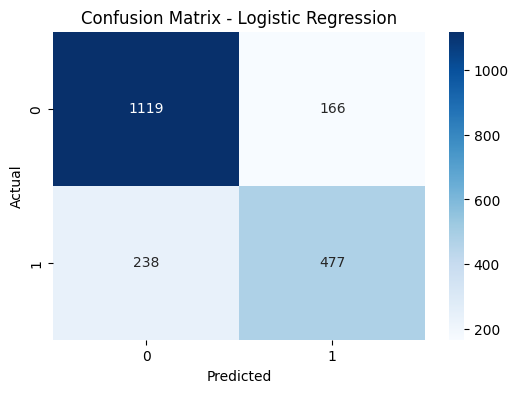


==================== Decision Tree ====================
Train Accuracy: 1.0000
Test Accuracy: 0.7695
Accuracy Score: 0.7695
Cross Validation Scores: [0.76875  0.745625 0.769375 0.77125  0.779375]
Mean Cross Validation Score: 0.7669

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.82      0.82      1285
           1       0.68      0.67      0.68       715

    accuracy                           0.77      2000
   macro avg       0.75      0.75      0.75      2000
weighted avg       0.77      0.77      0.77      2000



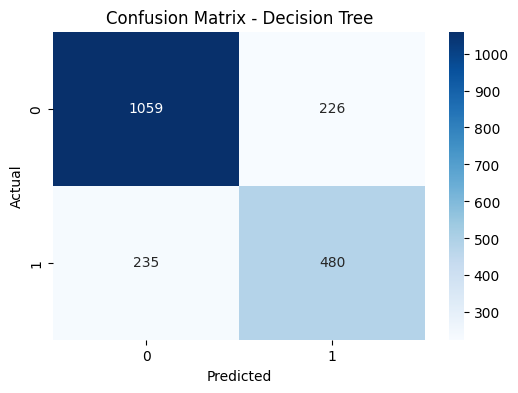


==================== Random Forest ====================
Train Accuracy: 1.0000
Test Accuracy: 0.8300
Accuracy Score: 0.8300
Cross Validation Scores: [0.8425   0.83875  0.838125 0.835625 0.843125]
Mean Cross Validation Score: 0.8396

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1285
           1       0.77      0.75      0.76       715

    accuracy                           0.83      2000
   macro avg       0.82      0.81      0.81      2000
weighted avg       0.83      0.83      0.83      2000



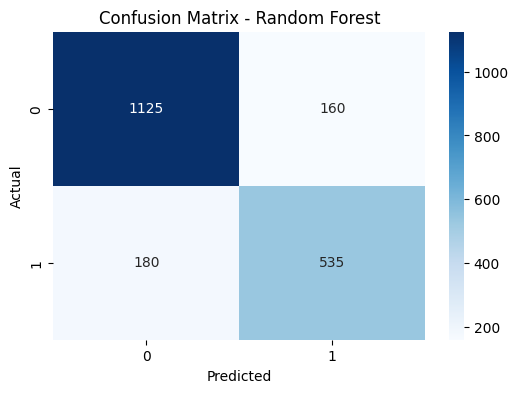


==================== Gradient Boosting ====================
Train Accuracy: 0.8815
Test Accuracy: 0.8480
Accuracy Score: 0.8480
Cross Validation Scores: [0.846875 0.855625 0.855625 0.853125 0.866875]
Mean Cross Validation Score: 0.8556

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.89      0.88      1285
           1       0.80      0.77      0.78       715

    accuracy                           0.85      2000
   macro avg       0.84      0.83      0.83      2000
weighted avg       0.85      0.85      0.85      2000



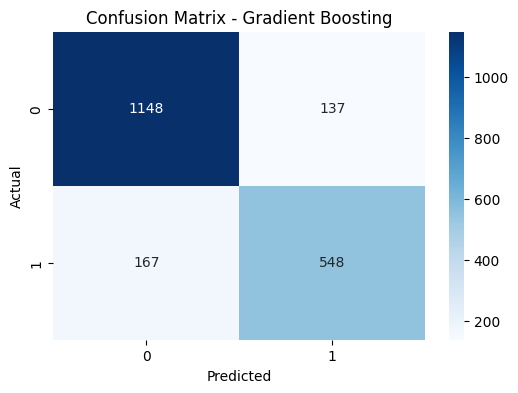


==================== Support Vector Machine ====================
Train Accuracy: 0.8735
Test Accuracy: 0.8125
Accuracy Score: 0.8125
Cross Validation Scores: [0.81625 0.80625 0.81625 0.80625 0.81625]
Mean Cross Validation Score: 0.8123

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.86      0.86      1285
           1       0.75      0.72      0.73       715

    accuracy                           0.81      2000
   macro avg       0.80      0.79      0.79      2000
weighted avg       0.81      0.81      0.81      2000



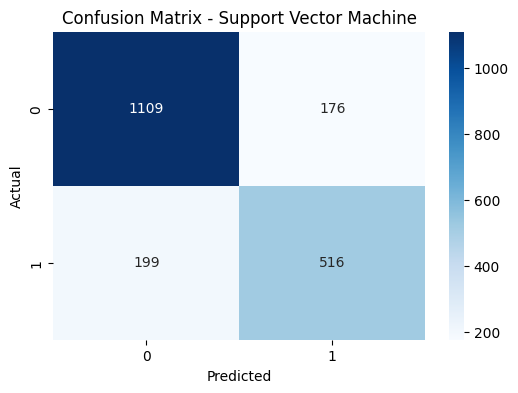

In [6]:
models = [
    (LogisticRegression(), "Logistic Regression"),
    (DecisionTreeClassifier(), "Decision Tree"),
    (RandomForestClassifier(n_estimators=100), "Random Forest"),
    (GradientBoostingClassifier(), "Gradient Boosting"),
    (SVC(), "Support Vector Machine")
]

for model, name in models:
    # Use scaled data for LR, SVM, and potentially others
    if name in ["Logistic Regression", "Support Vector Machine"]:
        evaluate_model(model, name, X_train_scaled, X_test_scaled, y_train, y_test)
    else:
        evaluate_model(model, name, X_train, X_test, y_train, y_test)